In [1]:
# import the libraries we need
import torch
from torch import nn
from torch.nn import functional as F
import random
import math
import re
import time
import numpy as np
import matplotlib.pyplot as plt
import datetime
import os
import zipfile
import shutil
from tqdm import tqdm
from collections import defaultdict

## Step 1: Tokenizer

The original vocabulary only had + and =. I added "-" so the model can handle both
subtraction operations (5-3=) and negative results (=-123). The token IDs after 9
therefore shift by one.

In [2]:
# special token
pad_token="[PAD]"
eos_token="[EOS]"

class character_level_tokenizer:
    """
    character-level
    """
    def __init__(self):
        self.vocab = [str(x) for x in range(10)] + ["+", "-", "="] + [pad_token, eos_token]
        self.token_to_id = {v : k for k, v in enumerate(self.vocab)}
        self.id_to_token = {k : v for k, v in enumerate(self.vocab)}
        self.ntokens = len(self.vocab)
        self.pattern = f"[^{re.escape(''.join(self.vocab))}]"

    def clean(self, text):
        """
        removes all characters not in the vocabulary
        """
        out = re.sub(self.pattern, "", text)
        return out

    def pre_tokenization(self, text):
        """
        character-level
        """
        return [c for c in text]

    def encode(self, text):
        text_list = self.pre_tokenization(self.clean(text))        
        return [self.token_to_id[c] for c in text_list]

    def decode(self, token_list):
        return "".join([self.id_to_token[i] for i in token_list])

In [3]:
tokenizer = character_level_tokenizer()

ntokens = tokenizer.ntokens
print(f'Number of tokens in the vocabulary: {ntokens}')

prompt = "12 + 42 = "
inputs = tokenizer.encode(prompt)
print(f'\nPrompt: {prompt}')
print(f'Input: {inputs}')
print(f'Input tokenized: {tokenizer.decode(inputs)}')


prompt_answer = "12 + 42 = 54"
inputs = tokenizer.encode(prompt_answer)
print(f'\nPrompt: {prompt_answer}')
print(f'Input: {inputs}')
print(f'Input tokenized: {tokenizer.decode(inputs)}')

Number of tokens in the vocabulary: 15

Prompt: 12 + 42 = 
Input: [1, 2, 10, 4, 2, 12]
Input tokenized: 12+42=

Prompt: 12 + 42 = 54
Input: [1, 2, 10, 4, 2, 12, 5, 4]
Input tokenized: 12+42=54


In [4]:
#subtraction test
prompt = "12-42=-30"
inputs = tokenizer.encode(prompt)
print(f'Input: {inputs}')
print(f'Input tokenized: {tokenizer.decode(inputs)}')

Input: [1, 2, 11, 4, 2, 12, 11, 3, 0]
Input tokenized: 12-42=-30


## Step 2: Data generation

The original `sample_datapoint` only produced additions. I now randomly pick "+" or
"-" for each sample so the dataset is a balanced mix of both operations. When b > a
the result is negative, and Python's `str()` already puts the minus sign in front,
so no extra handling is needed there.

`check_carries` only worked for addition. I extended it to also detect borrows in
subtraction, since carries and borrows are the cases we expect the model to find
hardest.

In [5]:
def sample_datapoint(number_digits = 3):
    """
    returns a string containing two random numbers with `number_digits` and the
    result of either their addition or their subtraction.
    """
    # generate operand 1
    a_list = [random.randint(0,9) for _ in range(number_digits)]
    a_int = int("".join([str(x) for x in a_list]))

    # generate operand 2
    b_list = [random.randint(0,9) for _ in range(number_digits)]
    b_int = int("".join([str(x) for x in b_list]))

    # randomly pick the operation so the dataset is a balanced mix
    op = random.choice(["+", "-"])
    result_int = a_int + b_int if op == "+" else a_int - b_int

    return (str(a_int) + op + str(b_int) + "=", str(result_int))


def check_carries(data_tuple):
    """
    Takes a tuple like ("910+263=", "1173") or ("123-456=", "-333").
    Returns a list indicating which output digits used an incoming carry (addition)
    or an incoming borrow (subtraction), sized to the length of the result digits.
    """
    equation, result_str = data_tuple

    # work out which operation was used
    op = "+" if "+" in equation else "-"
    operands = equation.replace("=", "").split(op)

    if op == "+":
        # the sum is never shorter than the operands, so size to the result
        number_digits = len(result_str)
        str_a = operands[0].zfill(number_digits)
        str_b = operands[1].zfill(number_digits)
    else:
        # the difference can be shorter than the operands (554-469=85), so size to
        # the larger operand instead, otherwise columns would be skipped
        a_int, b_int = int(operands[0]), int(operands[1])
        big, small = max(a_int, b_int), min(a_int, b_int)
        number_digits = len(str(big))
        str_a = str(big).zfill(number_digits)
        str_b = str(small).zfill(number_digits)

    carry = 0
    used_carry_flags = []

    # process column by column from right to left
    for i in reversed(range(number_digits)):
        digit_a = int(str_a[i])
        digit_b = int(str_b[i])

        # 1. record if this current column is USING an incoming carry / borrow
        used_carry_flags.append(carry)

        # 2. work out if this column generates one for the NEXT column
        if op == "+":
            carry = 1 if digit_a + digit_b + carry >= 10 else 0
        else:
            carry = 1 if digit_a - digit_b - carry < 0 else 0

    # reverse back to match standard left-to-right order
    used_carry_flags.reverse()
    return used_carry_flags


# check both operations
for _ in range(6):
    sample = sample_datapoint(3)
    print(sample, check_carries(sample))

('151+433=', '584') [0, 0, 0]
('239-340=', '-101') [0, 1, 0]
('628+722=', '1350') [1, 0, 1, 0]
('702+578=', '1280') [1, 0, 1, 0]
('763-110=', '653') [0, 0, 0]
('837+2=', '839') [0, 0, 0]


## Step 3: Build the dataset

I kept the tutorial's rejection sampling so there is no overlap between the train,
validation and test splits. Because subtraction is harder than addition, I also
check that the split is roughly balanced between the two operations.

In [6]:
# dataset parameters
number_digits = 3
train_size = 50000
val_size = 10000
test_size = 10000

data_train, data_val, data_test = [], [], []
data = []
while len(data) < (train_size + val_size + test_size):
    sample = sample_datapoint(number_digits)
    if not(sample in data):
        data.append(sample)
print(f"total of uniques samples {len(data)}")

data_train, data_val, data_test = data[:train_size], data[train_size: train_size+val_size], data[train_size+val_size : train_size+val_size+test_size]

# print some outputs
print(len(data_train), len(data_val), len(data_test))
print(data_train[:4], data_val[:4], data_test[:4])
print(set(data_train).intersection(set(data_val)), set(data_train).intersection(set(data_test)), set(data_val).intersection(set(data_test)))

# check the mix of operations in each split
for name, split in [("train", data_train), ("val", data_val), ("test", data_test)]:
    n_add = sum(1 for q, _ in split if "+" in q)
    n_sub = len(split) - n_add
    n_neg = sum(1 for _, r in split if r.startswith("-"))
    print(f"{name}: {n_add} additions, {n_sub} subtractions, {n_neg} negative results")

total of uniques samples 70000
50000 10000 10000
[('590-874=', '-284'), ('320+487=', '807'), ('470+584=', '1054'), ('231-978=', '-747')] [('928-400=', '528'), ('751+643=', '1394'), ('953-505=', '448'), ('556-469=', '87')] [('580+612=', '1192'), ('995+290=', '1285'), ('238-754=', '-516'), ('876-340=', '536')]
set() set() set()
train: 24940 additions, 25060 subtractions, 12502 negative results
val: 4918 additions, 5082 subtractions, 2537 negative results
test: 5043 additions, 4957 subtractions, 2486 negative results


In [7]:
data_carry = []
while len(data_carry) < 1000:
    sample = sample_datapoint(number_digits)
    if (not (sample in data)) and sum(check_carries(sample)) > 1:
        data_carry.append(sample)
print(len(data_carry), data_carry[:4])

1000 [('787+939=', '1726'), ('716-78=', '638'), ('948+344=', '1292'), ('447-543=', '-96')]


## Step 4: Positional encoding and model

The model architecture is unchanged from the workshop. The only difference is that
the vocabulary is now 15 tokens instead of 14, which the embedding layer picks up
automatically from `ntokens`.

In [8]:
class PositionalEncoding(nn.Module):
    r"""Inject some information about the relative or absolute position of the tokens in the sequence.
        The positional encodings have the same dimension as the embeddings, so that the two can be summed.
        Here, we use sine and cosine functions of different frequencies.
    .. math:
        \text{PosEncoder}(pos, 2i) = sin(pos/10000^(2i/d_model))
        \text{PosEncoder}(pos, 2i+1) = cos(pos/10000^(2i/d_model))
        \text{where pos is the word position and i is the embed idx)
    Args:
        d_model: the embed dim (required).
        dropout: the dropout value (default=0.1).
        max_len: the max. length of the incoming sequence (default=5000).
    """

    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        
        pe = torch.zeros(max_len, d_model)
        # TODO: compute positional ecoding
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp((torch.arange(0, d_model, 2).float() / d_model) * (-math.log(1e4)))
        pe[:, 0::2]= torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        
        # pytorch buffer
        self.register_buffer('pe', pe)

    def forward(self, x):
        r"""Inputs of forward function
        Args:
            x: the sequence fed to the positional encoder model (required).
        Shape:
            x: [sequence length, batch size, embed dim]
            output: [sequence length, batch size, embed dim]
        """
        # TODO: apply positional encoding
        x = x + self.pe[:x.size(0)]
        return x

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


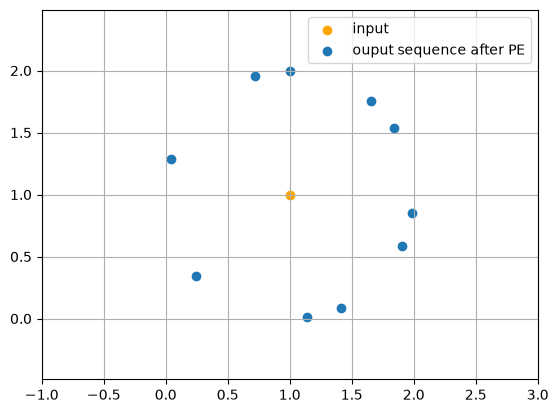

In [9]:
PE = PositionalEncoding(d_model=2,dropout=0)
# create tensor with the same vector
x = torch.ones((10,1,2)) #[seq lenght x batch x dim]
# apply PE and check out the result
y = PE(x)

# plot
plt.scatter(1,1,c='orange',label='input')
plt.scatter(y[:,0,0],y[:,0,1],label='ouput sequence after PE')
plt.axis('equal')
plt.xlim((-1,3))
plt.ylim((-1,3))
plt.grid('on')
plt.legend()

In [10]:
class CustomEncoderLayer(nn.TransformerEncoderLayer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.attn_weights = None

    def forward(self, src, src_mask=None, src_key_padding_mask=None, **kwargs):
        # Capture the attention weights by setting need_weights=True
        src2, attn_weights = self.self_attn(
            src, src, src,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=False  # (B, num_heads, S, S)
        )
        self.attn_weights = attn_weights
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src

class TransformerModel(nn.Module):
    def __init__(self, ntoken, ninp, nhead, nhid, nlayers, dropout=0.5):
        super().__init__()
        self.input_emb = nn.Embedding(ntoken, ninp)
        self.pos_encoder = PositionalEncoding(ninp, dropout)
        encoder_layers = CustomEncoderLayer(ninp, nhead, nhid, 0.1)
        self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)
        self.decoder = nn.Linear(ninp, ntoken)
        self.ninp = ninp
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        nn.init.uniform_(self.input_emb.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)

    def _generate_square_subsequent_mask(self, sz):
        # generate a LxL casual attention mask
        return torch.log(torch.tril(torch.ones(sz,sz)))

    def forward(self, src):        
        mask = self._generate_square_subsequent_mask(len(src)).to(src.device)
        # TODO: Inference of the model
        src = self.input_emb(src) * math.sqrt(self.ninp)
        src = self.pos_encoder(src)
        output_enc = self.encoder(src, mask=mask) 
        output_dec = self.decoder(output_enc)
        # Gather attention maps from all encoder layers
        attention_maps = [layer.attn_weights for layer in self.encoder.layers]
        return F.log_softmax(output_dec, dim=-1), output_enc, attention_maps

In [11]:
# instantiate the model and check it
model = TransformerModel(ntoken = ntokens,
                         ninp = 128,
                         nhead = 16,
                         nhid = 64,
                         nlayers = 6)
print(model)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

# size of the model
model.train()
Nparams = sum(p.numel() for p in model.parameters())
Nparams_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'parameters: {Nparams}, trainable parameters: {Nparams_train}')

TransformerModel(
  (input_emb): Embedding(15, 128)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x CustomEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): Linear(in_features=128, out_features=15, bias=True)
)
cuda


/tmp/ipykernel_475/3270049067.py:29: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)


parameters: 502671, trainable parameters: 502671


## Step 5: Generation

The generate function is unchanged from the workshop. It feeds the prompt in, takes
the token with the highest probability at the last position, appends it to the
sequence, and repeats. Since the model is not trained yet the output will be
meaningless — this is just checking the function runs.

In [12]:
def generate(model, prompts, new_tokens = 5):
    input_tensor = prompts # (length_prompts, batch_size)
    input_tensor = input_tensor.to(device)
    for _ in range(new_tokens):
        output, _, _ = model(input_tensor) # n x b x v
        last_output = output[-1, :, :] # b x v
        token = torch.argmax(last_output, -1).view((1, -1)) # 1 x B
        input_tensor = torch.cat((input_tensor, token), 0) # (n+1) x B
    return input_tensor

In [13]:
# try to generate 5 new tokens
model.eval()
prompt = "2+3="
print(f'prompt: {prompt}')
prompt_tensor = torch.tensor(tokenizer.encode(prompt)).view((-1,1))
print(f'prompt encoded: {prompt_tensor}')
output = generate(model, prompt_tensor, new_tokens = 5).view((1,-1))
print(f'output: {output}')
print(f'output decoded: {tokenizer.decode(output.tolist()[0])}')


# let try this with bathces
print()
prompts = ["2+3=", "5+1="]
print(f'prompt: {prompts}')
prompt_tensor = torch.cat([torch.tensor(tokenizer.encode(prompt)).view((-1,1)) for prompt in prompts], 1)
print(f'prompt encoded: {prompt_tensor}')
output = generate(model, prompt_tensor, new_tokens = 5)
print(f'output: {output}')
print(f'output decoded:\n{"\n".join([tokenizer.decode(output[:, 0].tolist()), tokenizer.decode(output[:, 1].tolist())])}')

prompt: 2+3=
prompt encoded: tensor([[ 2],
        [10],
        [ 3],
        [12]])
output: tensor([[ 2, 10,  3, 12,  3, 12,  3, 12,  3]], device='cuda:0')
output decoded: 2+3=3=3=3

prompt: ['2+3=', '5+1=']
prompt encoded: tensor([[ 2,  5],
        [10, 10],
        [ 3,  1],
        [12, 12]])
output: tensor([[ 2,  5],
        [10, 10],
        [ 3,  1],
        [12, 12],
        [ 3,  3],
        [12, 12],
        [ 3,  0],
        [12, 12],
        [ 3,  0]], device='cuda:0')
output decoded:
2+3=3=3=3
5+1=3=0=0


In [14]:
# check the same function works with a subtraction prompt
prompt = "12-42="
prompt_tensor = torch.tensor(tokenizer.encode(prompt)).view((-1,1))
output = generate(model, prompt_tensor, new_tokens = 5).view((1,-1))
print(f'prompt: {prompt}')
print(f'output decoded: {tokenizer.decode(output.tolist()[0])}')

prompt: 12-42=
output decoded: 12-42=11111


## Step 6: Padding

The padding function is unchanged from the workshop. Prompts are left-padded so
they all end at the "=" position, and answers are right-padded after an EOS token.
This works for subtraction without modification because the minus sign is just
another token.

In [15]:
def pad(token_list, type_list = "prompts"):
    assert type_list in ['prompts', 'answers']
    # pad so that all the prompt have the same number of tokens
    max_length = max([len(x) for x in token_list])
    out = []
    for x in token_list:
        if type_list == "prompts":
            out.append([tokenizer.token_to_id[pad_token]] * (max_length - len(x)) + x) # padding + sequence
        if type_list == "answers":
            out.append(x + [tokenizer.token_to_id[eos_token]] + [tokenizer.token_to_id[pad_token]] * (max_length - len(x))) # sequence + eos + padding                    
    return out, max_length

In [16]:
prompts = [tokenizer.encode("1+0="), tokenizer.encode("21+35=")]
answers = [tokenizer.encode("1"), tokenizer.encode("56")]
padded_prompts, _ = pad(prompts, "prompts")
padded_answers, _ = pad(answers, "answers")
for p in prompts: 
    print(f'Prompts : {tokenizer.decode(p)}')
for p in answers: 
    print(f'Answers : {tokenizer.decode(p)}')
for p in padded_prompts: 
    print(f'Prompts padded: {tokenizer.decode(p)}')
for p in padded_answers:
    print(f'Answers padded: {tokenizer.decode(p)}')

Prompts : 1+0=
Prompts : 21+35=
Answers : 1
Answers : 56
Prompts padded: [PAD][PAD]1+0=
Prompts padded: 21+35=
Answers padded: 1[EOS][PAD]
Answers padded: 56[EOS]


## Step 7: Batching and evaluation

`get_batch`, `evaluate` and the printing helper are unchanged from the workshop.

`errorTest` needed one small fix. It converts the decoded strings to integers with
`int()`, which is fine when the only possible characters are digits. With
subtraction a wrong prediction can produce something like "1-2" or "--3", and
`int()` raises a ValueError on those, so I wrapped the conversion in a helper that
falls back to 0. This follows the same fallback the workshop already had for empty
strings.

In [17]:
batch_size=100
def get_batch(data, i):
    prompts = [tokenizer.encode(data[i][0]) for i in range(i, i + batch_size)]
    padded_prompts, length_prompts = pad(prompts, "prompts")
    answers = [tokenizer.encode(data[i][1]) for i in range(i, i + batch_size)]
    padded_answers, length_answers = pad(answers, "answers")
    X = torch.stack([torch.tensor(x) for x in padded_prompts], 1)
    Y = torch.stack([torch.tensor(x) for x in padded_answers], 1)
    return X, Y, length_prompts, length_answers

# create a batch for training from position 243 until 243 + batchsie
X, Y, length_prompts, length_answers = get_batch(data_train, 243)
X.shape, Y.shape, length_prompts, length_answers

(torch.Size([8, 100]), torch.Size([5, 100]), 8, 4)

In [18]:
model.eval()
prompt_tensor, answers_tensor, length_prompts, length_answers = get_batch(data_carry, 0)  
output_tensor = generate(model, prompt_tensor, 5)

# formatted print
w_out, w_prm, w_ans, w_prd = 50, 15, 15, 15
print(f"\n\n{'Output':<{w_out}} | {'Prompt':<{w_prm}} | {'Answer':<{w_ans}} | {'Predicted':<{w_prd}}")
print("-" * (w_out + w_prm + w_ans + w_prd + 9)) # Creates a perfect matching underline

# 3. Transpose or slice inside your loop
for i in range(10):
    # Decode everything into clean strings right away
    output_str    = tokenizer.decode(output_tensor[:, i].tolist())
    prompt_str    = tokenizer.decode(prompt_tensor[:, i].tolist())
    answer_str    = tokenizer.decode(answers_tensor[:, i].tolist())
    
    # Corrected slice index to use the slice logic from your original code
    predicted_str = tokenizer.decode(output_tensor[length_prompts:, i].tolist())
    
    # 4. Print with clean left-alignment (<) and fixed character boundaries
    print(f"{output_str:<{w_out}} | {prompt_str:<{w_prm}} | {answer_str:<{w_ans}} | {predicted_str:<{w_prd}}")



Output                                             | Prompt          | Answer          | Predicted      
--------------------------------------------------------------------------------------------------------
787+939======                                      | 787+939=        | 1726[EOS]       | =====          
[PAD]716-78=1=3=3                                  | [PAD]716-78=    | 638[EOS][PAD]   | 1=3=3          
948+344===3==                                      | 948+344=        | 1292[EOS]       | ==3==          
447-543==3===                                      | 447-543=        | -96[EOS][PAD]   | =3===          
644+166=32323                                      | 644+166=        | 810[EOS][PAD]   | 32323          
738+339==3=3=                                      | 738+339=        | 1077[EOS]       | =3=3=          
384-433=3333=                                      | 384-433=        | -49[EOS][PAD]   | 3333=          
790+772======                                      | 

In [19]:
def evaluate(input_data):
    # compute how many digits are correctly predicted
    # Turn on evaluation mode disables dropout.
    model.eval()
    correct_digit, total_digit, correct, total = 0., 0., 0. ,0.
    with torch.no_grad():
        for batch, i in enumerate(range(0, len(input_data) - 1, batch_size)):            
            prompts, target_answers, length_prompts, length_answers = get_batch(input_data, i)            
            prompts         = prompts.to(device) # (length_prompts, batch_size)
            target_answers  = target_answers.to(device) # (length_answers + 1, batch_size)
            
            output          = generate(model, prompts, length_answers + 1) # (length_prompts + length_answers + 1, batch_size)
            answers_tokens  = output[length_prompts:, :] # (length_answers + 1, batch_size), contains tokens

            # compare predictions
            target_mask_pad = target_answers != tokenizer.token_to_id[pad_token]
            equality_test = answers_tokens == target_answers    
            
            # compute digit and sequence accuracy
            correct_digit += torch.logical_and(target_mask_pad, equality_test).sum().item()
            total_digit += target_mask_pad.sum().item()

            # full sequence accuracy computation
            # compute sequence accuracy
            correct += torch.all(torch.logical_or(~target_mask_pad, equality_test), axis=0).float().sum().item()
            total += target_answers.shape[-1]
            
        
        # compute digit and sequence accuracy
        digit_accuracy = correct_digit / total_digit
        seq_accuracy = correct / total
        
    return digit_accuracy, seq_accuracy
    
def safe_int(s):
    """
    Converts a decoded answer string to an integer.
    A wrong prediction can produce a malformed string such as "1-2" or "--3",
    which int() cannot parse. Those are counted as 0, following the same fallback
    the workshop already used for empty strings.
    """
    try:
        return int(s)
    except ValueError:
        return 0
        
def errorTest(input_data):
    # convert model answer and target to integers
    # Turn on evaluation mode disables dropout.
    model.eval()
    num_ans = []
    num_tgt = []
    with torch.no_grad():
        for batch, i in enumerate(range(0, len(input_data) - 1, batch_size)):            
            # predict on a batch
            prompts, target_answers, length_prompts, length_answers = get_batch(input_data, i)            
            prompts         = prompts.to(device) # (length_prompts, batch_size)
            target_answers  = target_answers.to(device) # (length_answers + 1, batch_size)
            output          = generate(model, prompts, length_answers + 1) # (length_prompts + length_answers + 1, batch_size)
            answers_tokens  = output[length_prompts:, :] # (length_answers + 1, batch_size), contains tokens
            
            # compute the numerical error between tgt and answer
            n_d,n_b = answers_tokens.shape
            for idx,b in enumerate(range(n_b)):
                # go through the batch
                ans         = tokenizer.decode(answers_tokens[:,b].tolist())
                tgt         = tokenizer.decode(target_answers[:,b].tolist())
                
                ans_cleaned = ans.replace('[EOS]', '').replace('[PAD]', '')
                tgt_cleaned = tgt.replace('[EOS]', '').replace('[PAD]', '')
                
                num_ans.append(safe_int(ans_cleaned))
                num_tgt.append(safe_int(tgt_cleaned))
    num_ans = torch.tensor(num_ans)
    num_tgt = torch.tensor(num_tgt)
    return num_ans,num_tgt

test_digit_accuracy, test_seq_accuracy = evaluate(data_carry)
test_digit_accuracy, test_seq_accuracy

(0.04227500544780998, 0.0)

In [ ]:
learning_rate = 1e-3
epochs = 40
batch_size = 100
model = TransformerModel(ntoken = ntokens,
                         ninp = 128,
                         nhead = 16,
                         nhid = 64,
                         nlayers = 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# train step
def train_epoch(epoch):
    model.train()
    

    total_loss = 0.
    n_batch = 0
    iterable = range(0, len(data_train) - 1, batch_size)
    for batch, i in tqdm(enumerate(iterable),total=len(iterable),colour='GREEN'):
        n_batch += 1        
        prompts, target_answers, length_prompts, length_answers = get_batch(data_train, i)  
        prompts         = prompts.to(device) # (length_prompts, batch_size)
        target_answers  = target_answers.to(device) # (length_answers, batch_size) 
        input_tensor    = torch.cat((prompts, target_answers), 0) # (length_prompts + length_answers, batch_size)        
        optimizer.zero_grad()               
                    
        output, _, _ = model(input_tensor) # (length_prompts + length_answers, batch_size, ntokens)
        output_answers  = output[length_prompts-1:-1,:,:].reshape(-1, ntokens) # (length_answers * batch_size, ntokens)
        target_answers  = target_answers.view(-1) # length_answers * batch_size        
        loss = F.cross_entropy(output_answers, target_answers)
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
   
    total_loss  /= n_batch
    train_digit_accuracy, train_seq_accuracy   = evaluate(data_train)
    
    return total_loss, train_digit_accuracy, train_seq_accuracy
    
# test step
def test_epoch(epoch=1):
    model.eval()

    total_loss = 0.
    n_batch = 0
    iterable = range(0, len(data_val) - 1, batch_size)
    for batch, i in tqdm(enumerate(iterable),total=len(iterable)):
        n_batch += 1
        prompts, target_answers, length_prompts, length_answers = get_batch(data_val, i)
        prompts         = prompts.to(device) # (length_prompts, batch_size)
        target_answers  = target_answers.to(device) # (length_answers, batch_size)
        input_tensor    = torch.cat((prompts, target_answers), 0) # (length_prompts + length_answers, batch_size)
        
        with torch.no_grad():        
            output, _, _ = model(input_tensor) # (length_prompts + length_answers, batch_size, ntokens)
        output_answers  = output[length_prompts-1:-1,:,:].reshape(-1, ntokens) # (length_answers * batch_size, ntokens)
        target_answers  = target_answers.view(-1)
        
        loss = F.cross_entropy(output_answers, target_answers)
            
        total_loss += loss.item()

    total_loss /= n_batch
    test_digit_accuracy, test_seq_accuracy  = evaluate(data_val)
    
    return total_loss, test_digit_accuracy, test_seq_accuracy

# actual loop
def train():
    train_losses4disp   = []
    test_losses4disp    = []
    test_digit_accuracy4disp  = []
    train_digit_accuracy4disp = []
    test_seq_accuracy4disp  = []
    train_seq_accuracy4disp = []
    
    AUAC_test   = 0
    AUAC_train  = 0
    best_test_accuracy = None
    test_digit_accuracy, test_seq_accuracy = evaluate(data_val)
    print('-' * 89)
    print('| initialisation | val digit accuracy {:5.3f} | val seq accuracy {:5.3f}'.format(test_digit_accuracy, test_seq_accuracy))
    print('-' * 89)
    training_start_time = time.time()
    for epoch in range(1, epochs+1):
        epoch_start_time            = time.time()
        train_loss,train_digit_accuracy,train_seq_accuracy   = train_epoch(epoch)
        test_loss,test_digit_accuracy,test_seq_accuracy     = test_epoch(epoch)
                
        train_losses4disp.append(train_loss)
        test_losses4disp.append(test_loss)
        train_digit_accuracy4disp.append(train_digit_accuracy)
        test_digit_accuracy4disp.append(test_digit_accuracy)
        train_seq_accuracy4disp.append(train_seq_accuracy)
        test_seq_accuracy4disp.append(test_seq_accuracy)
                
        # keep the checkpoint with the best validation sequence accuracy
        if best_test_accuracy is None or test_seq_accuracy > best_test_accuracy:
            best_test_accuracy = test_seq_accuracy
            torch.save(model.state_dict(), genName + "_best.pth")
                
        # print('-' * 50)
        str_epoch = 'Epoch {:3d} ({:5.2f}s), val digit accuracy:{:5.3f}, val seq accuracy:{:5.3f}, train digit accuracy:{:5.3f}, train seq accuracy:{:5.3f}, loss:{:5.3}'.format(
            epoch, (time.time() - epoch_start_time), test_digit_accuracy, test_seq_accuracy, train_digit_accuracy, train_seq_accuracy, train_loss)
        print(str_epoch)
    
    total_training_time = (time.time()-training_start_time)/(60)
    str_time = f'Total training time: {total_training_time:.2f} min\n'
    print(str_time)
    return np.array(train_losses4disp), np.array(test_losses4disp),\
           np.array(test_digit_accuracy4disp), np.array(train_digit_accuracy4disp),\
            np.array(test_seq_accuracy4disp), np.array(train_seq_accuracy4disp),\
           (str_epoch,str_time)    


datename  = datetime.datetime.now().strftime('%Yy%mm%dd-%Hh%Mm%Ss')
genName   = datename + "-LLMForward" 
train_losses4disp, test_losses4disp, test_digit_accuracy4disp, train_digit_accuracy4disp, test_seq_accuracy4disp, train_seq_accuracy4disp, str_results = train()
str_epoch,str_time = str_results
torch.save(model.state_dict(), genName + ".pth")

# training/validation plots
f   = plt.figure(figsize=(12,6),dpi=120) # A4 format, square
plt.rc('font',size= 8)
#%%   losses plot
ax  = f.add_subplot(1,1,1)
ax.plot( np.log10(1.+test_losses4disp),color='b',label='test',linewidth=1)
ax.plot( np.log10(1.+train_losses4disp),color='b',linestyle='--',label='train',linewidth=1)
ax.set_xlabel("epoch")
ax.set_ylabel("log-loss",color='b')
ax.tick_params(axis='y', labelcolor='b')
ax.set_title(str_epoch)
ax.legend(loc='center left')
plt.grid()

#%%   accuracy plot
ax2 = ax.twinx()
ax2.plot( test_seq_accuracy4disp ,color='green',label='test',linewidth=1)
ax2.plot( train_seq_accuracy4disp ,color='green',linestyle='--',label='train',linewidth=1)
ax2.set_xlabel("epoch")
ax2.set_ylabel("Test accuracy ",color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc = 'center right')
ax2.set_ylim((0,1)) 
plt.grid()

f.suptitle(genName)
plt.tight_layout

/tmp/ipykernel_475/3270049067.py:29: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)


cuda
-----------------------------------------------------------------------------------------
| initialisation | val digit accuracy 0.064 | val seq accuracy 0.000
-----------------------------------------------------------------------------------------


100%|██████████| 100/100 [00:00<00:00, 183.34it/s]


Epoch   1 (21.21s), val digit accuracy:0.507, val seq accuracy:0.008, train digit accuracy:0.510, train seq accuracy:0.008, loss: 1.33


100%|██████████| 100/100 [00:00<00:00, 183.12it/s]


...

100%|██████████| 100/100 [00:00<00:00, 185.28it/s]


Epoch  37 (21.01s), val digit accuracy:0.998, val seq accuracy:0.992, train digit accuracy:0.998, train seq accuracy:0.993, loss:0.0489


100%|██████████| 100/100 [00:00<00:00, 185.60it/s]


Epoch  38 (21.07s), val digit accuracy:0.998, val seq accuracy:0.993, train digit accuracy:0.999, train seq accuracy:0.994, loss:0.057


 74%|███████▍  | 370/500 [00:07<00:02, 48.19it/s]

In [ ]:
print("val seq accuracy per epoch:")
print(np.round(test_seq_accuracy4disp, 3))

In [ ]:
# final check on the held-out test set
test_digit_accuracy, test_seq_accuracy = evaluate(data_test)
print(f"Test digit accuracy: {test_digit_accuracy:.4f}")
print(f"Test seq accuracy:   {test_seq_accuracy:.4f}")

In [ ]:
# split the test set by operation to compare addition vs subtraction
# get_batch always takes exactly batch_size samples, so trim each subset to a
# multiple of batch_size to avoid running past the end of the list
data_test_add = [d for d in data_test if "+" in d[0]]
data_test_sub = [d for d in data_test if "-" in d[0]]

data_test_add = data_test_add[:(len(data_test_add) // batch_size) * batch_size]
data_test_sub = data_test_sub[:(len(data_test_sub) // batch_size) * batch_size]

for name, subset in [("addition", data_test_add), ("subtraction", data_test_sub)]:
    d_acc, s_acc = evaluate(subset)
    print(f"{name:12s} n={len(subset):5d}  digit acc={d_acc:.4f}  seq acc={s_acc:.4f}")

In [ ]:
import pickle

# save the held-out test set so both modes are evaluated on exactly the same data
with open('data_test.pkl', 'wb') as f:
    pickle.dump(data_test, f)

# save the forward results for the comparison in main_report
forward_results = {
    'val_seq_accuracy_per_epoch': test_seq_accuracy4disp,
    'train_seq_accuracy_per_epoch': train_seq_accuracy4disp,
    'val_loss_per_epoch': test_losses4disp,
    'train_loss_per_epoch': train_losses4disp,
    'test_digit_accuracy': test_digit_accuracy,
    'test_seq_accuracy': test_seq_accuracy,
}
with open('results_forward.pkl', 'wb') as f:
    pickle.dump(forward_results, f)

print("saved data_test.pkl and results_forward.pkl")